<a href="https://colab.research.google.com/github/RahafAlowais1/Dummy-Customer-Data-Analysis-Using-Python/blob/main/sentiment_analysis_STC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing stc Customer Experience through Natural Language Processing (NLP)

## Data Cleaning


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/content/stc_tweets_after_final_cleaning_ver5.csv')

data

,Unnamed: 0,id,created_at,date,user_id,name,retweet,nlikes,nreplies,nretweets,tweet4
0,0,1353913978834051073,1.611633e+12,2021-01-26 03:53:41,177757484,NOHY✨ البراقة,False,0,1,0,سحبتو مني مبلغ لشحن رصيد طريق ماي اس سي تواصلت...
1,1,1353709940901371904,1.611585e+12,2021-01-25 14:22:55,1280687902364745731,B..,False,2,2,0,اذا رقمك شغال وعندك نسخه واتس اب السحابه بالوا...
2,2,1353470988319653888,1.611528e+12,2021-01-24 22:33:24,2569667586,A&....,False,0,1,0,اشتراك stc للمنصه روح ل stc واسالهم طريقته الا...
3,3,1353426146621235201,1.611517e+12,2021-01-24 19:35:13,584766522,a7sas asmar,False,0,1,0,شوي وأحد يمنشني الله يسعدكم شكلي الليله مداوم ...
4,4,1353417040816713729,1.611515e+12,2021-01-24 18:59:02,408119559,Rehab. 👩🏻‍💻,False,0,1,0,اقدر اطلع بدل فاقد تطبيق ماي اس سي
...,...,...,...,...,...,...,...,...,...,...,...
10821,10826,551460881625014274,1.420313e+12,2015-01-03 19:31:34,152641509,العناية بالعملاء stc السعودية,False,0,0,0,مرحبا بإمكانك الاطلاع كمية البيانات المتبقيه ا...
10822,10827,551446748250787840,1.420310e+12,2015-01-03 18:35:24,152641509,العناية بالعملاء stc السعودية,False,0,0,0,مرحبا لمعرفة عروض مسبق الدفع ارجو الإطلاع تطبي...
10823,10828,551446022434877440,1.420310e+12,2015-01-03 18:32:31,152641509,العناية بالعملاء stc السعودية,False,0,0,0,مرحبا لمعرفة عروض مسبق الدفع ارجو الإطلاع تطبي...
10824,10829,550948181543227392,1.420191e+12,2015-01-02 09:34:17,152641509,العناية بالعملاء stc السعودية,False,0,0,0,"اهلا وسهلا , , , بامكانك الاطلاع تفاصيل الباقة..."


In [3]:
data.head(5)

,Unnamed: 0,id,created_at,date,user_id,name,retweet,nlikes,nreplies,nretweets,tweet4
0,0,1353913978834051073,1.611633e+12,2021-01-26 03:53:41,177757484,NOHY✨ البراقة,False,0,1,0,سحبتو مني مبلغ لشحن رصيد طريق ماي اس سي تواصلت...
1,1,1353709940901371904,1.611585e+12,2021-01-25 14:22:55,1280687902364745731,B..,False,2,2,0,اذا رقمك شغال وعندك نسخه واتس اب السحابه بالوا...
2,2,1353470988319653888,1.611528e+12,2021-01-24 22:33:24,2569667586,A&....,False,0,1,0,اشتراك stc للمنصه روح ل stc واسالهم طريقته الا...
3,3,1353426146621235201,1.611517e+12,2021-01-24 19:35:13,584766522,a7sas asmar,False,0,1,0,شوي وأحد يمنشني الله يسعدكم شكلي الليله مداوم ...
4,4,1353417040816713729,1.611515e+12,2021-01-24 18:59:02,408119559,Rehab. 👩🏻‍💻,False,0,1,0,اقدر اطلع بدل فاقد تطبيق ماي اس سي


In [4]:
data.tail(5)

,Unnamed: 0,id,created_at,date,user_id,name,retweet,nlikes,nreplies,nretweets,tweet4
10821,10826,551460881625014274,1.420313e+12,2015-01-03 19:31:34,152641509,العناية بالعملاء stc السعودية,False,0,0,0,مرحبا بإمكانك الاطلاع كمية البيانات المتبقيه ا...
10822,10827,551446748250787840,1.420310e+12,2015-01-03 18:35:24,152641509,العناية بالعملاء stc السعودية,False,0,0,0,مرحبا لمعرفة عروض مسبق الدفع ارجو الإطلاع تطبي...
10823,10828,551446022434877440,1.420310e+12,2015-01-03 18:32:31,152641509,العناية بالعملاء stc السعودية,False,0,0,0,مرحبا لمعرفة عروض مسبق الدفع ارجو الإطلاع تطبي...
10824,10829,550948181543227392,1.420191e+12,2015-01-02 09:34:17,152641509,العناية بالعملاء stc السعودية,False,0,0,0,"اهلا وسهلا , , , بامكانك الاطلاع تفاصيل الباقة..."
10825,10830,550854981461737472,1.420169e+12,2015-01-02 03:23:56,152641509,العناية بالعملاء stc السعودية,False,0,0,0,يمكنك معرفة المتبقي اشتراكك خلال موقع الجوال ن...


In [5]:
data.shape

(10826, 11)

In [6]:
data.dtypes

,0
Unnamed: 0,int64
id,int64
created_at,float64
date,object
user_id,int64
name,object
retweet,bool
nlikes,int64
nreplies,int64
nretweets,int64


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10826 entries, 0 to 10825
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  10826 non-null  int64  
 1   id          10826 non-null  int64  
 2   created_at  10826 non-null  float64
 3   date        10826 non-null  object 
 4   user_id     10826 non-null  int64  
 5   name        10826 non-null  object 
 6   retweet     10826 non-null  bool   
 7   nlikes      10826 non-null  int64  
 8   nreplies    10826 non-null  int64  
 9   nretweets   10826 non-null  int64  
 10  tweet4      10824 non-null  object 
dtypes: bool(1), float64(1), int64(6), object(3)
memory usage: 856.5+ KB


In [8]:
# 1. تحديد العمود واسماء الحسابات المراد حذفها
user_col = 'name'
staff_names = ['العناية بالعملاء stc السعودية', 'stccare', 'stc_ksa', 'stc السعودية']

# 2. تحديث المتغير data وحذف الموظفين
data = data[~data[user_col].isin(staff_names)].copy()

# 3. طباعة التأكيد (اختياري)
print(f"✅ تم تحديث متغير data بنجاح.")
print(f"📊 البيانات الحالية تحتوي على {len(data)} سجل للعملاء فقط.")

✅ تم تحديث متغير data بنجاح.
📊 البيانات الحالية تحتوي على 8356 سجل للعملاء فقط.


In [9]:
data.shape

(8356, 11)

In [10]:
data = data.drop(columns=['Unnamed: 0','id', 'created_at','date', 'user_id', 'name', 'retweet',
       'nlikes', 'nreplies', 'nretweets'])
data.columns

Index(['tweet4'], dtype='object')

In [11]:
data = data.rename (columns= {'tweet4' :'Tweets'}) # تعديل اسماء الكولم

data. columns

Index(['Tweets'], dtype='object')

In [12]:
data.head(100)
data.tail(30)

,Tweets
10635,ممكن ألقى منكم تجاوب تطبيق ماي اس سي نزلتة الج...
10655,اواجه مشكلة الاستفادة نقاط قطاف والسبب وجود رق...
10657,اواجه مشكلة الاستفادة نقاط قطاف والسبب وجود رق...
10658,كونكت ماي فاي فور جي شريحة بيانات اس سي محدود ...
10659,كونكت ماي فاي فور جي شريحة بيانات مفتوح اس سي ...
10679,ماقدرت ادخل ماي اس تى سى مافى طريقه ثانيه
10683,نزل تطبيق ماي اس سي
10692,جيد نوعا عندي ماي فاي اس سي فور جي افضل بكثير ...
10693,عندي برنامج ماي اس سي ﻻكن احول رصير طريق البرن...
10694,نزلي تطبيق ماي اس سي جييييد ويخدم


In [13]:
data.describe(include='object')

,Tweets
count,8354
unique,3922
top,ماي اس سي
freq,100


In [14]:
data['Tweets'].value_counts()

,count
Tweets,
ماي اس سي,100
تطبيق ماي اس سي,78
طريق تطبيق ماي اس سي,36
هوا مبين الشريحه شغاله نفس موقع ماي اس سي ولاكن الجوال مي شغاله رساله تجي اي برنامج ايش المشكله والحل طيب,20
طريق ماي اس سي,18
...,...
اذا شريحتك زين لازم تروح للفرع ويلغون شريحتك ويفعلونه الكترونيًا ( رسوم اصدار شريحة ﷼ ) اما اذا اس سي تطلب ماي اس سي ويجيك مندوب ( مجانًا ) تضيفه لجوالك طريق باركود الاعدادات اعتقد انك تقدر تضيف الى شرايح تشغل بنفس الوقت الا شريحتين,2
اذا رقمك سوا ادخلي ماي اس سي وتحت مكتوب قطاف وموجوده الاماكن اللي يمديك تحاسبين ماقد جربت للامانه بنده🦧,1
ارجع رقمي للشحن ماابغى مفوتر شوفلي صرفه ورقمي مفصول وفيه شي وكل ادخل ماي اس سي وابي احول احصل شي مقفل عندي ياليت تساعدوني بشي الحين اكثر ثلاث شهور وش الحل,1


In [15]:
data['Tweets'].value_counts()[0:5] ##اول خمسة تكررو



,count
Tweets,
ماي اس سي,100
تطبيق ماي اس سي,78
طريق تطبيق ماي اس سي,36
هوا مبين الشريحه شغاله نفس موقع ماي اس سي ولاكن الجوال مي شغاله رساله تجي اي برنامج ايش المشكله والحل طيب,20
طريق ماي اس سي,18


In [16]:
data['Tweets'].value_counts()[-5:]

,count
Tweets,
اذا شريحتك زين لازم تروح للفرع ويلغون شريحتك ويفعلونه الكترونيًا ( رسوم اصدار شريحة ﷼ ) اما اذا اس سي تطلب ماي اس سي ويجيك مندوب ( مجانًا ) تضيفه لجوالك طريق باركود الاعدادات اعتقد انك تقدر تضيف الى شرايح تشغل بنفس الوقت الا شريحتين,2
اذا رقمك سوا ادخلي ماي اس سي وتحت مكتوب قطاف وموجوده الاماكن اللي يمديك تحاسبين ماقد جربت للامانه بنده🦧,1
ارجع رقمي للشحن ماابغى مفوتر شوفلي صرفه ورقمي مفصول وفيه شي وكل ادخل ماي اس سي وابي احول احصل شي مقفل عندي ياليت تساعدوني بشي الحين اكثر ثلاث شهور وش الحل,1
اخواني ممكن تفهموني طلبت شريحة eaim ماي اس سي اقدر افعلها واستلمها نفس البرنامج مايحتاج اروح للفرع,1
شحنت طريق تطبيق ماي اس سي بالصرافه ، وقال فشل وبنفس اللحظة خصم المبلغ حسابي وش المشكلة,1


In [17]:
data.duplicated().sum()

np.int64(4433)

In [18]:
data.drop_duplicates(subset=['Tweets'], keep='first', inplace=True)

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data.isnull().sum()

,0
Tweets,1


In [21]:
data=data.dropna()

In [22]:
data.isnull().sum()

,0
Tweets,0


In [23]:
data.shape

(3922, 1)

In [24]:
import re
  # تنظيف النصوص
def professional_clean(text):
    text = str(text)

    # 1. إزالة الروابط والمنشن
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)

    # 2. إزالة التشكيل (الفتحة، الضمة، إلخ)
    tashkeel_pattern = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = re.sub(tashkeel_pattern, '', text)

    # 3. إزالة الرموز والزخارف (مع الحفاظ على الإيموجي والكلمات)
    # هذه الخطوة تحذف مثل: -*- , _ , | , []
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)

    # 4. معالجة المسافات الزائدة
    text = " ".join(text.split())

    return text

#  تطبيقها على العامود
data['Tweets'] = data['Tweets'].apply(professional_clean)

In [25]:
data.shape

(3922, 1)

In [26]:
data.head(80)
data.tail(30)

,Tweets
5221,ممكن ألقى منكم تجاوب تطبيق ماي اس سي نزلتة الج...
5241,اواجه مشكلة الاستفادة نقاط قطاف والسبب وجود رق...
5244,كونكت ماي فاي فور جي شريحة بيانات اس سي محدود ...
5245,كونكت ماي فاي فور جي شريحة بيانات مفتوح اس سي ...
5265,ماقدرت ادخل ماي اس تى سى مافى طريقه ثانيه
5278,جيد نوعا عندي ماي فاي اس سي فور جي افضل بكثير ...
5279,عندي برنامج ماي اس سي ﻻكن احول رصير طريق البرن...
5280,نزلي تطبيق ماي اس سي جييييد ويخدم
5284,ماي فاي آس سي يشغل الشرائح با ريال راوتر آس سي...
5291,لگم تطبيق ماي إس سي ع نظام الأندرويد


In [27]:
unwanted_patterns = ['سگے بندے', 'آخ تھووووو', 'تسی وی بندے']

# حذف أي تغريدة تحتوي على هذه الكلمات
for pattern in unwanted_patterns:
    data = data[~data['Tweets'].str.contains(pattern, na=False)]

In [28]:
data.head(80)
data.tail(90)

,Tweets
4908,اديرخدماتي بواسطة ماي اس سي وتحويل نقاط قطاف
4913,تطبيق ماي اس سي يعمل بصوره جيده بالواي فاي
4918,سلام عليكم عندي مشكلة تسجيل الدخول لبرنامج ماي...
4923,توظفت تويتر وشات بتطبيق ماي اس سي وتسويق اصعب ...
4926,طريق تطبيق ماي اس سي امس محول لرقمي الثاني قطا...
...,...
5393,السلام عليكم شريحتي تقفلت ورقم الpuk الي بتطبي...
5399,حاولت تقديم بلاغ طريق ماي اس سي البرنامج يعمل ...
5456,اذا رقمك سوا ادخلي ماي اس سي وتحت مكتوب قطاف و...
5457,اخواني ممكن تفهموني طلبت شريحة eaim ماي اس سي ...


In [29]:

output_file = 'stc_arabic_tweets_output.csv'

def contains_arabic(text):
    # هذا النمط يبحث عن أي حرف في نطاق الحروف العربية
    arabic_pattern = re.compile(r'[\u0600-\u06FF]+')
    return bool(arabic_pattern.search(str(text)))

# إبقاء التغريدات التي تحتوي على حروف عربية على الأقل
df = data[data['Tweets'].apply(contains_arabic)]

# 6. حفظ وتيحمل الملف
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print("\n✅ تم التحديث! الملف جاهز الآن.")



✅ تم التحديث! الملف جاهز الآن.


In [30]:
data.shape

(3921, 1)

## Sentiment Analysis


In [31]:
from IPython.lib.display import exists
from transformers import pipeline
from tqdm import tqdm
import os
from google.colab import files
from huggingface_hub import login

# 1. تسجيل الدخول
login("")

# 2. إعدادات الملفات
input_file = '/content/stc_arabic_tweets_output.csv'
output_file = '/content/stc_sentiment_Analysis_output_final.csv'


# 3. تحميل البيانات
if os.path.exists(input_file):
    df_results = pd.read_csv(input_file) # قراءة الملف

    df_results = df_results.drop_duplicates(subset=['Tweets']) #حذف التغريدات المكررة
else:
    print(" ❌ لم يتم العثور على ملف المدخلات ")
    exists()


# 4. تحميل الموديل المخصص للهجة السعودية (SaudiBERT)
model_id = "faisalq/SaudiBERT"
print(f"جاري تحميل المحرك السعودي ({model_id})...")
sentiment_analyzer = pipeline("sentiment-analysis", model=model_id)


# 5. دالة التحليل
def get_sentiment_final_tuned(text):
    text_str = str(text) # تحويل الى نص

  #  تنظيف النص
    # حذف الروابط لتقليل التشويش على الموديل
    text_cleaned = re.sub(r'http\S+', '', text_str)
    # حذف توقيع الموظف (شكراً + اسم) لضمان عدم احتساب رد الموظف كإيجابية عميل
    text_cleaned = re.sub(r"(شكراً|شكرا)\s+[\u0600-\u06FF]+\s*$", '', text_cleaned).strip()

    if len(text_cleaned) < 5:
        return 'LABEL_1', 0.0 # Return neutral if text is too short after cleaning

  #  توحيف الاحرف العربية
    text_norm = re.sub("[إأآ]", "ا", text_cleaned) # تحويل كل أشكال الألف إلى ا
    text_norm = re.sub("ى", "ي", text_norm)      # تحويل الألف المقصورة إلى ي
    text_norm = re.sub("ة", "ه", text_norm)      # تحويل التاء المربوطة إلى ه


    try:

        # كلمات مفتاحية إيجابية قوية في السياق السعودي
        pos_words = [
    'كفو', 'ممتاز', 'بطل', 'اشكركم', 'تسلمون', 'عظيم', 'رائع', 'ممتازه',
    'افضل', 'اقوي', 'جميل', 'احسنت', 'مبروك', 'توفير', 'خصومات', 'هديه',
    'مجاني', 'سهل', 'سريع', 'جوده', 'نظيف', 'مميز', 'مميزه', 'رائعه',
    'رائعين', 'نشكركم', 'متوفر', 'الاصدار']

        #  كلمات مفتاحية سلبية قوية في السيق السعودي
        neg_words = [
    'فاشل', 'نصب', 'سيء جدا', 'اسوا', 'خايس', 'سرقه', 'زفت', 'مشكله',
    'بلاغ', 'تعبت', 'بطيء', 'يقطع', 'مخيس', 'صعب', 'معقد', 'غالي',
    'مرتفع', 'ضعيف', 'لا يوجد', 'مقطوع', 'ما يشتغل', 'عطل', 'شلتوا',
    'فصل', 'حجب', 'خطا', 'للاسف', 'تاخير', 'تخفيض', 'الغاء', 'احتيال',
    'نقص', 'نقصان', 'غير راضي', 'انقطاع', 'خربان', 'تعليق']


        # تصنيف بناء على الكلمات المفتاحية
        if any(w in  text_norm for w in neg_words):
            return 'LABEL_0', 0.90 # ثقة عالية في السلبية

        if any(w in  text_norm for w in pos_words):
            return 'LABEL_2', 0.95 # ثقة عالية في الإيجابية


        #  التحليل الأساسي عبر SaudiBERT
        res = sentiment_analyzer(text_cleaned[:512])[0]
        base_label = res['label']
        base_score = res['score']

 #LABEL_0: تعني سلبي (Negative). LABEL_1: تعني محايد/طبيعي (Neutral). LABEL_2: تعني إيجابي (Positive).


        # إذا كان التصنيف ايجابي/سلبي ولكن بثقة منخفضة يعتبره طبيعي
        if base_score < 0.6 and base_label != 'LABEL_1':
            return 'LABEL_1', base_score

        # نتيجة الموديل الأساسية مع توحيد المسميات
        final_label = 'LABEL_1'
        if base_label in ['Negative', 'LABEL_0']:
            final_label = 'LABEL_0'
        elif base_label in ['Positive', 'LABEL_2']:
            final_label = 'LABEL_2'


        return final_label, base_score

    except Exception as e:
        # في حالة حدوث أي خطأ، نعود بتصنيف 'طبيعي' مع ثقة منخفضة
        return "LABEL_1", 0.0


# 6. تشغيل المعالجة
print("بدء التحليل فائق الدقة والمعدّل باستخدام SaudiBERT...")
tqdm.pandas()
# تطبيق الدالة على عمود التغريدات
df_results[['raw_label', 'confidence']] = df_results['Tweets'].progress_apply(lambda x: pd.Series(get_sentiment_final_tuned(x)))


# 7. تحديث المسميات النهائية للعرض
mapping = {'LABEL_0': 'سلبي', 'LABEL_1': 'طبيعي', 'LABEL_2': 'إيجابي'}
df_results['sentiment_label'] = df_results['raw_label'].map(mapping)


# 8. الحفظ والتحميل
df_results.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n✅ اكتمل التحليل بدقة عالية! الملف جاهز: {output_file}")


جاري تحميل المحرك السعودي (faisalq/SaudiBERT)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/630 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/575M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

بدء التحليل فائق الدقة والمعدّل باستخدام SaudiBERT...


100%|██████████| 3903/3903 [06:53<00:00,  9.44it/s]


✅ اكتمل التحليل بدقة عالية! الملف جاهز: /content/stc_sentiment_Analysis_output_final.csv


In [32]:
print('                --- عينة عشوائية من نتائج تحليل المشاعر ---')
display(df_results[['Tweets', 'sentiment_label','confidence']].sample(n=10))
print('                        --- نهاية العينة ---'      )

                --- عينة عشوائية من نتائج تحليل المشاعر ---


,Tweets,sentiment_label,confidence
2743,طالع بتطبيق ماي اس سي ان الفروع الحولي الاجهزة...,طبيعي,0.507638
3606,رح اقرب سوبر ماركت و قله أبغى كويك نت ثلاث شهو...,طبيعي,0.522877
400,السلام عليكم ورحمة الله ايام والنت مقطوع والتو...,سلبي,0.900000
1526,اطلبه ماي اس سي,طبيعي,0.549029
2966,التسجيل ماي اس سي يرفض تسجيلي راجعت اقرب فرع ص...,طبيعي,0.558415
3092,شفيه تطبيق ماي اس سي مو راضي يشتغل معي مكتوب ا...,إيجابي,0.950000
3230,باقة اربع شهور قيقا متوفره تطبيق ماي اس سي موجوده,إيجابي,0.950000
726,استطيع الدخول علي ماي اس سي يطلع رقم البطاقة غلط,طبيعي,0.528613
2371,اذا شريحتك سوا حمل تطبيق ماي اس سي وتطلع,طبيعي,0.512169
260,السلام عليكم ياخوي تطبيق ماي اس سي اتعبني يقول...,سلبي,0.900000


                        --- نهاية العينة ---


## Sentiment Word Clouds


In [33]:
pip install python-bidi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 6.0 MB/s eta 0:00:00


In [34]:
pip install arabic_reshaper

جاري إنشاء سحابة الكلمات الإيجابية)...


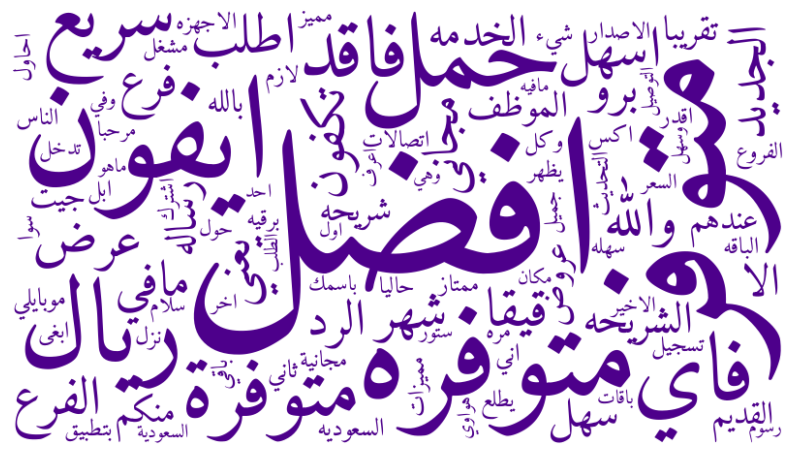

جاري إنشاء سحابة الكلمات السلبية...


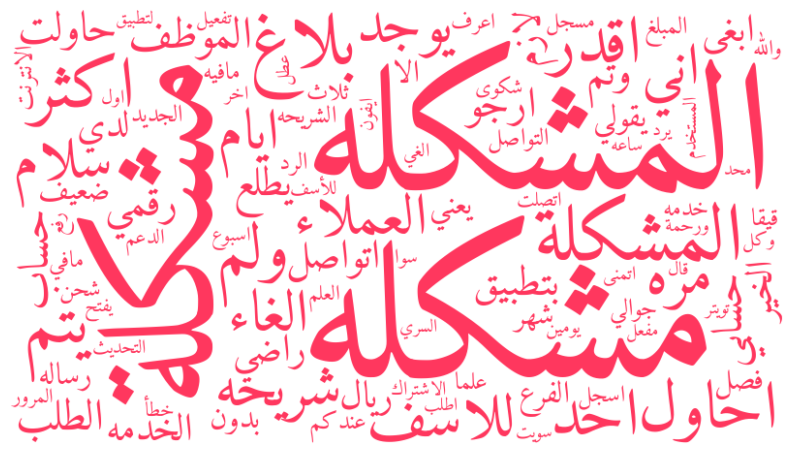

In [41]:
import os
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
import requests
from collections import Counter

# 1. تحميل الخط العربي
font_url = 'https://github.com/google/fonts/raw/main/ofl/amiri/Amiri-Regular.ttf'
arabic_font = 'Amiri-Regular.ttf'
if not os.path.exists(arabic_font):
    response = requests.get(font_url)
    with open(arabic_font, 'wb') as f_font:
        f_font.write(response.content)

# 2. تحميل البيانات
try:
    df_results = pd.read_csv('/content/stc_sentiment_Analysis_output_final.csv')
except FileNotFoundError:
    print("خطأ: لم يتم العثور على ملف البيانات!")

# 3. دالة حساب تكرار الكلمات
def get_frequencies(texts):
    stop_words = [
        "من", "في", "على", "التي", "تم", "اللي", "عن", "هذا", "كان", "بس", "السلام" ,"عندي" , "عليكم" ,"الان", "علي", "ايش", "الله" , "يقول" ,"عندك" ,"طريق",
        "stc", "تطبيق", "ماي", "اس", "سي", "وشكرا", "ارسل", "خلال", "اذا", "انه", "ان", "لو", "كانت", "كنت", "كل", "قبل", "بعد", "حتى",
        "ام", "او", "ما", "عن", "مع", "هذه", "هنا", "هناك", "الي", "اللى", "الى","واذا", "يا", "انا", "انت", "احنا", "هم", "اليوم", "الحين", "وين", "ليش",
        "نفس", "موجودة", "موجود", "موجوده", "راح", "عشان", "ممكن", "بدل", "مثل", "الشي", "شي", "وانا", "ليه", "لأن", "لان", "الارقام", "رقم",
        "الرقم", "داخل", "يكون", "يكونون", "بطلب", "طلب", "طلبت", "دخلت", "ادخل", "التطبيق", "تطبيق", "برنامج", "البرنامج", "شريحة", "الشريحة",
        "جهاز", "الجهاز", "باقة", "الباقة", "الاتصالات", "شركة", "الشركة", "الفواتير", "فاتورة", "جدا", "جداً", "يوم", "وقت", "صار", "عبر", "اخوي",
        "البيانات", "بيانات", "النت", "نت", "جوال", "الجوال", "الموقع", "موقع", "الدخول", "دخول", "اتصال", "اتصل","الاتصال", "الحل", "معي",
        "معكم", "ابغي", "ابي", "تواصل", "الخاص", "بخدمتكم", "حياك", "خدمة", "الخدمة", "مفوتر","مفوترة","مفوتره", "رقمك", "اهلا", "اهلاً", "نسعد"
    ]
    all_words = []
    for text in texts:
        text = re.sub(r'http\S+|@\S+|#\S+|[^\u0600-\u06FF\s]', ' ', str(text))
        words = text.split()
        for w in words:
            if w not in stop_words and len(w) > 2:
                reshaped = arabic_reshaper.reshape(w)
                all_words.append(reshaped)
    return Counter(all_words)

# 4. دالة رسم السحابة
def plot_final_wordcloud(df, label, text_color):
    subset = df[df["sentiment_label"] == label]["Tweets"]
    if subset.empty: return

    word_freq = get_frequencies(subset)
    if not word_freq: return


    purple_bg = "#4B0082"


    wc = WordCloud(
        width=800, height=450,
        background_color='white',
        font_path=arabic_font,
        color_func=lambda *args, **kwargs: text_color,
        collocations=False,
        max_words=100
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")

    title_reshaped = get_display(arabic_reshaper.reshape(f""))
    plt.title(title_reshaped, fontsize=18, fontweight='bold', pad=15, color="black")
    plt.show()

# 5. توليد السحابات بالألوان المحددة
print("جاري إنشاء سحابة الكلمات الإيجابية)...")
plot_final_wordcloud(df_results, 'إيجابي', "#4d008b")

print("جاري إنشاء سحابة الكلمات السلبية...")
plot_final_wordcloud(df_results, 'سلبي', '#ff375e')

جاري إنشاء سحابة الكلمات الطبيعية...


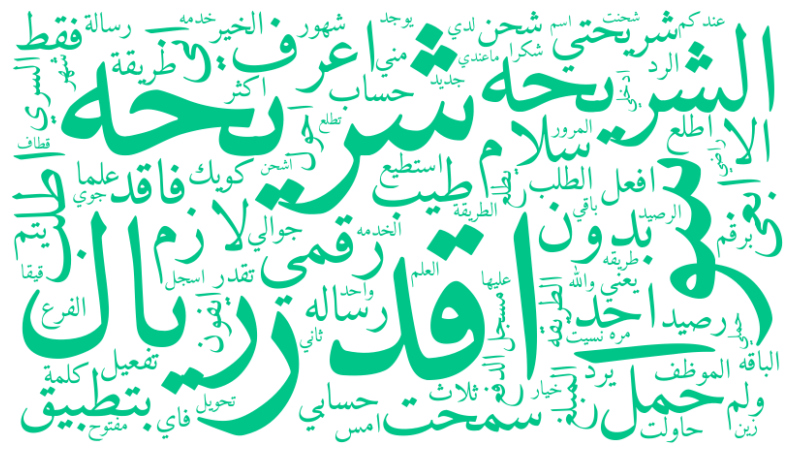

In [38]:
# 6. توليد وعرض سحابة الكلمات للمشاعر الطبيعية (Neutral)
print("جاري إنشاء سحابة الكلمات الطبيعية...")

# استدعاء الدالة الموحدة
plot_final_wordcloud(df_results, 'طبيعي', '#00c588')

## Data Visualization & Insights

/tmp/ipykernel_2074/2269969050.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, palette=colors, edgecolor='black', linewidth=0.5)
/tmp/ipykernel_2074/2269969050.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(reshaped_labels, fontsize=12)


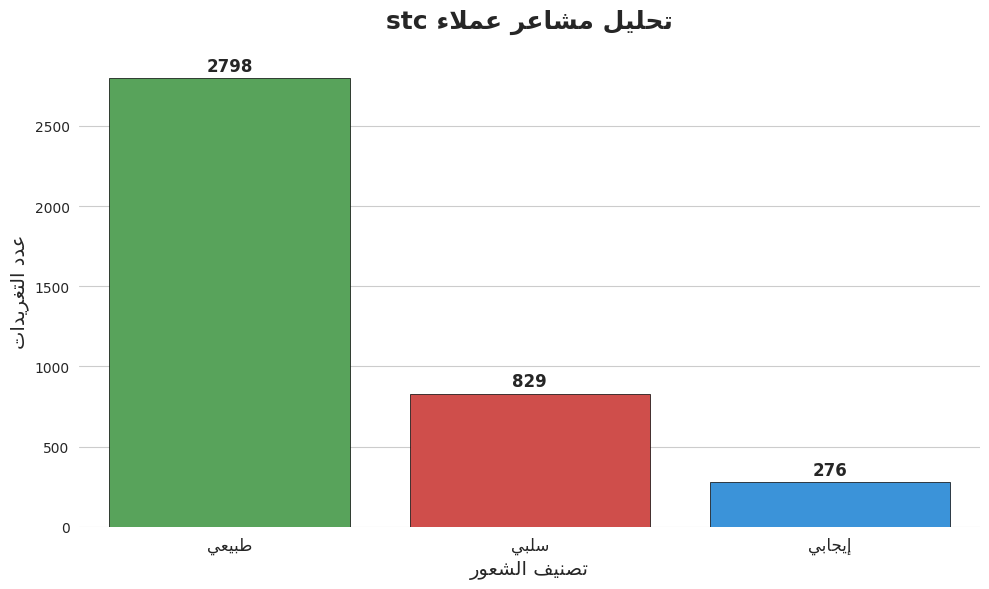

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تجهيز البيانات وحساب التكرارات
sentiment_counts = df_results['sentiment_label'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# 2. إعداد مساحة الرسم (الخلفية والنمط)
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 3. رسم الأعمدة مع اختيار ألوان
colors = {'إيجابي': '#2196F3', 'سلبي': '#E53935', 'طبيعي':'#4CAF50'}
ax = sns.barplot(x='Sentiment', y='Count', data=sentiment_counts, palette=colors, edgecolor='black', linewidth=0.5)

# 4. معالجة النصوص العربية للعناوين والمحاور
title_text = get_display(arabic_reshaper.reshape('تحليل مشاعر عملاء stc'))
x_label = get_display(arabic_reshaper.reshape('تصنيف الشعور'))
y_label = get_display(arabic_reshaper.reshape('عدد التغريدات'))

plt.title(title_text, fontsize=18, fontweight='bold', pad=20)
plt.xlabel(x_label, fontsize=14)
plt.ylabel(y_label, fontsize=14)

# 5. إضافة الأرقام (تسميات البيانات) فوق كل عمود
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

# 6. إعادة تشكيل أسماء التصنيفات على المحور الأفقي (إيجابي، سلبي، طبيعي)
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in sentiment_counts['Sentiment']]
ax.set_xticklabels(reshaped_labels, fontsize=12)

# 7. تحسين المظهر النهائي وحذف الحدود غير الضرورية
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

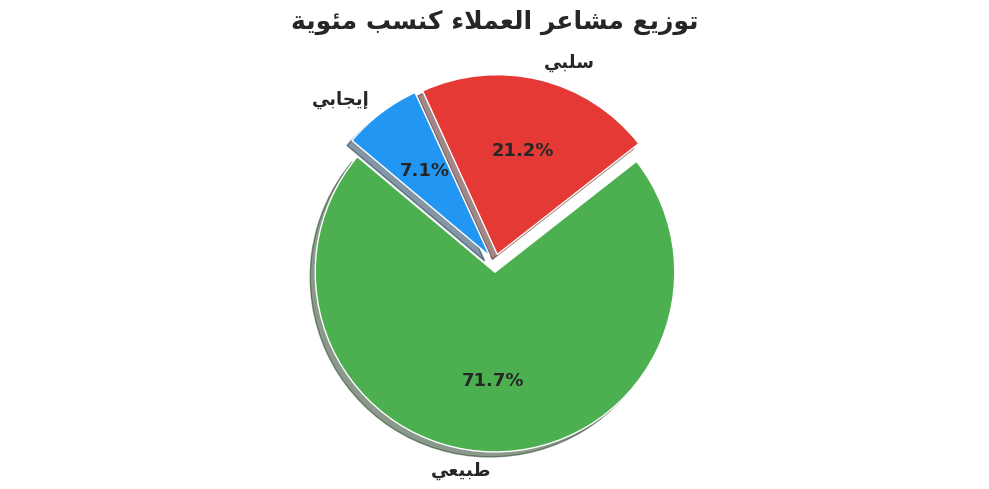

In [40]:

# 1. حساب النسب المئوية لكل تصنيف
sentiment_percentages = df_results['sentiment_label'].value_counts(normalize=True).mul(100).reset_index()
sentiment_percentages.columns = ['Sentiment', 'Percentage']

# 2. إعداد النصوص العربية لتظهر بشكل صحيح في الرسم
reshaped_pie_labels = [get_display(arabic_reshaper.reshape(label)) for label in sentiment_percentages['Sentiment']]
title_text = get_display(arabic_reshaper.reshape('توزيع مشاعر العملاء كنسب مئوية'))

# 3. إعدادات الجمالية: تحديد الألوان وتأثير الفصل (Explode) لإبراز جزء معين
explode = [0.05] * len(sentiment_percentages)
colors = ['#4CAF50', '#E53935', '#2196F3'] # درجات ألوان متناسقة

# 4. رسم "الفطيرة" (Pie Chart)
plt.figure(figsize=(10, 5)) # حجم مربع لضمان دائرية الرسم
plt.pie(sentiment_percentages['Percentage'],
        labels=reshaped_pie_labels,
        autopct='%1.1f%%',       # إظهار النسبة المئوية بفاصلة عشرية واحدة
        colors=colors,
        startangle=140,          # تدوير الرسم لزاوية رؤية أفضل
        explode=explode,         # إضافة مسافة بسيطة بين القطاعات
        shadow=True,             # إضافة ظل لإعطاء عمق (3D effect بسيط)
        textprops={'fontsize': 13, 'fontweight': 'bold'})

# 5. إضافة العنوان النهائي
plt.title(title_text, fontsize=18, fontweight='bold', pad=20)

# 6. ضمان رسمها كدائرة كاملة وحفظ التنسيق
plt.axis('equal')
plt.tight_layout()
plt.show()